# Лабораторна робота №3: Візуалізація багатовимірних даних у Python
**Виконав:** Студент групи ФБ-46 — Ільченко Владислав
**Технологічний стек:** Python, Pandas, NumPy, Matplotlib, Seaborn, Requests

In [1]:
%matplotlib inline
import sys

# Автоматичне встановлення seaborn прямо під час запуска, якщо пакет відсутній
try:
    import seaborn as sns
except ModuleNotFoundError:
    print("📦 Встановлюємо відсутні бібліотеки у фоновому режимі...")
    !{sys.executable} -m pip install seaborn requests -q
    import seaborn as sns

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Пряме зчитування з URL — Pandas робить це миттєво в один потік
url = "https://raw.githubusercontent.com/selva86/datasets/master/Cars93_miss.csv"
df = pd.read_csv(url)

# Швидке очищення даних від пропусків (Data Cleaning)
df['Price'] = df['Price'].fillna(df['Price'].mean())
df['Horsepower'] = df['Horsepower'].fillna(df['Horsepower'].mean())
df['MPG.city'] = df['MPG.city'].fillna(df['MPG.city'].median())
df.dropna(subset=['Manufacturer', 'Type', 'Cylinders'], inplace=True)

# Налаштування єдиного стилю відображення графіків
sns.set_theme(style="whitegrid")

print("=== ДАНІ ЗАВАНТАЖЕНО ТА ОЧИЩЕНО МИТТЄВО ===")
print(f"Розмірність матриці даних: {df.shape}")

=== ДАНІ ЗАВАНТАЖЕНО ТА ОЧИЩЕНО МИТТЄВО ===
Розмірність матриці даних: (81, 27)


### Крок 2. Візуалізація залежності ціни автомобіля від потужності двигуна (Scatter Plot)
*Дослідження взаємозв'язку між кінськими силами та вартістю авто з групуванням точок за типом кузова.*

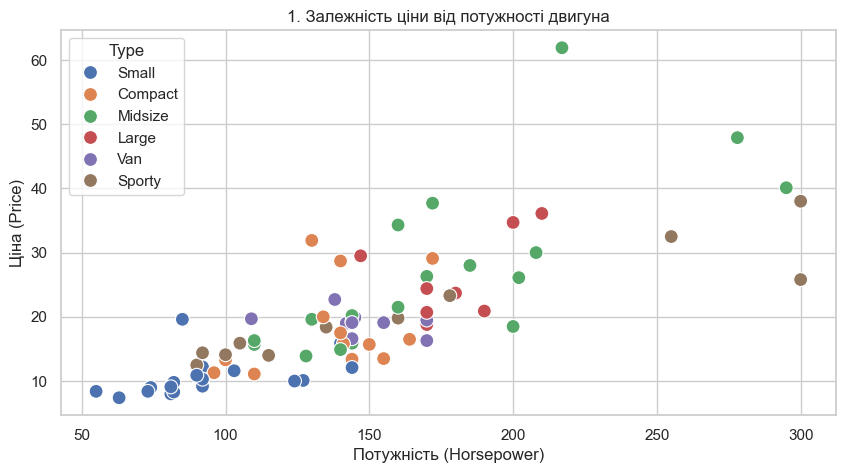

In [2]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='Horsepower', y='Price', hue='Type', s=100)
plt.title('1. Залежність ціни від потужності двигуна')
plt.xlabel('Потужність (Horsepower)')
plt.ylabel('Ціна (Price)')
plt.show()

### Крок 3. Дослідження розподілу цін на автомобілі (Гістограма з 5 діапазонами та лінією KDE)
*Аналіз щільності розподілу вартості автомобілів для виявлення найбільш представленого цінового сегмента на ринку.*

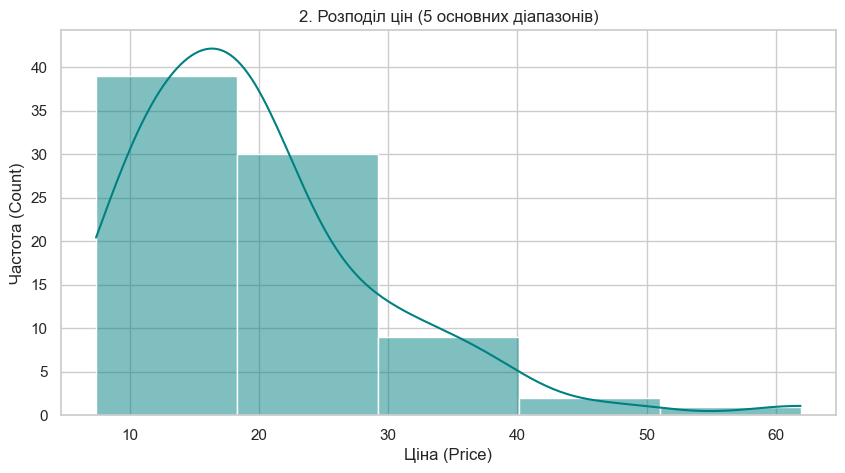

In [3]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Price'], bins=5, color='teal', kde=True)
plt.title('2. Розподіл цін (5 основних діапазонів)')
plt.xlabel('Ціна (Price)')
plt.ylabel('Частота (Count)')
plt.show()

### Крок 4. Аналіз тренду зміни вартості автомобіля залежно від об’єму паливного бака (Line Plot)
*Візуалізація загальної тенденції та напрямку зміни ціни при збільшенні місткості паливного бака.*

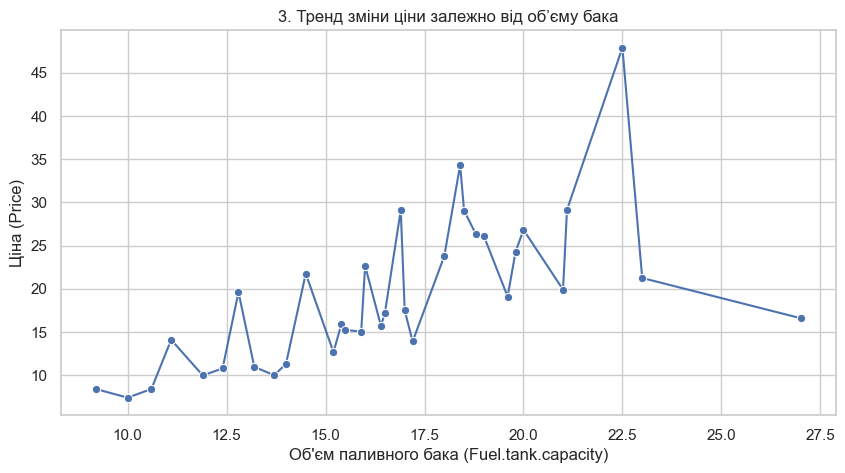

In [4]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='Fuel.tank.capacity', y='Price', errorbar=None, marker='o')
plt.title('3. Тренд зміни ціни залежно від об’єму бака')
plt.xlabel('Об\'єм паливного бака (Fuel.tank.capacity)')
plt.ylabel('Ціна (Price)')
plt.show()

### Крок 5. Статистичний аналіз розкиду та варіативності цін за типами кузова (Box Plot)
*Аналіз медіани, квартилів та аномальних викидів вартості автомобілів для різних категорій машин.*

C:\Users\Джарвис\AppData\Local\Temp\ipykernel_105772\1827143970.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Type', y='Price', palette='Set2')


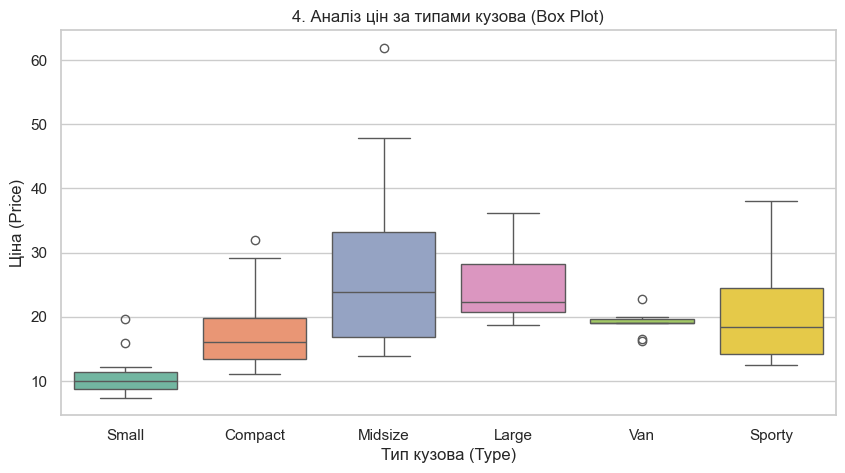

In [5]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Type', y='Price', palette='Set2')
plt.title('4. Аналіз цін за типами кузова (Box Plot)')
plt.xlabel('Тип кузова (Type)')
plt.ylabel('Ціна (Price)')
plt.show()

### Крок 6. Порівняльний аналіз середньої потужності автомобілів виробництва США та інших країн (Bar Plot)
*Стовпчикова діаграма для оцінки середнього показника кінських сил залежно від географічного походження бренду.*

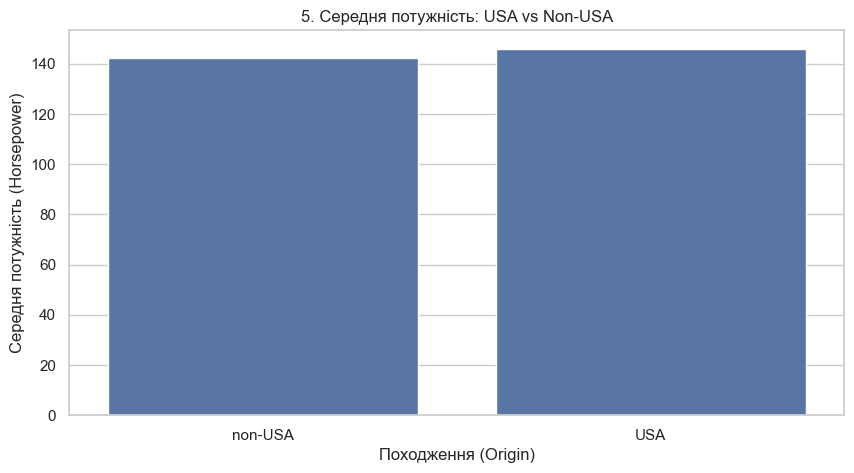

In [6]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='Origin', y='Horsepower', estimator=np.mean, errorbar=None)
plt.title('5. Середня потужність: USA vs Non-USA')
plt.xlabel('Походження (Origin)')
plt.ylabel('Середня потужність (Horsepower)')
plt.show()

### Крок 7. Дослідження лінійних взаємозв'язків між числовими атрибутами (Матриця кореляції Heatmap)
*Побудова теплової карти коефіцієнтів кореляції Пірсона між усіма числовими стовпчиками датасету.*

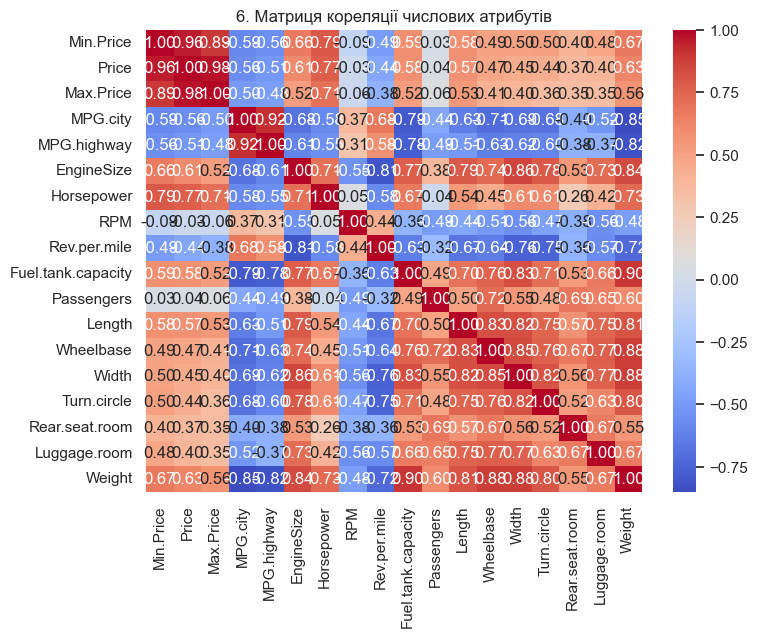

In [7]:
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('6. Матриця кореляції числових атрибутів')
plt.show()